# Lab 05 — Build a Symbolic Wordle Expert

**Goal:** build a deterministic non-neural player that can serve as both a performance reference and a teacher for later synthetic-data generation.

Qwen is not used in this lab.

That is the point.

Lab 04 showed that the untouched model can produce valid-looking Wordle guesses but has essentially no reliable state use. Before we train it, we need an expert that can answer two questions exactly:

1. Which answers are still possible?
2. Among those possibilities, which next guess is informative?

By the end of this lab you should have:

- the original Wordle answer lexicon;
- exact candidate filtering using the Lab 03 scorer;
- a compact encoding for all 243 possible feedback patterns;
- Shannon entropy over guess partitions;
- a deterministic candidate-only expert policy;
- a solver that plays complete games;
- benchmark results for the expert;
- infrastructure we can reuse directly in Lab 06.

We intentionally start with a **candidate-only** expert: every proposed guess must itself still be a possible answer. This is simpler than searching every legal probe word and is already a strong baseline. We can broaden the guess space later if evidence justifies the complexity.

## 5.1 Load the Wordle environment

We reuse the trusted scorer from Lab 03.

Do not rewrite Wordle semantics inside the expert. One scorer remains the source of truth.

In [1]:
from __future__ import annotations

from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from urllib.request import urlopen
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tiny_wordle.game import Turn, filter_candidates, score_string

## 5.2 Load a fixed answer lexicon

For these training labs we use the **original Wordle answer list**: 2,315 candidate answers.

This is not the same thing as claiming it is the current NYT answer set. The NYT later began curating answers dynamically. We want a fixed research environment, so the original list is actually useful.

The notebook downloads the list once and caches it under `../data/`.

Source: cfreshman's archived original Wordle answer list.

In [2]:
DATA_DIR = Path("../data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

ANSWERS_PATH = DATA_DIR / "wordle-answers-original.txt"

ANSWERS_URL = (
    "https://gist.githubusercontent.com/cfreshman/"
    "a03ef2cba789d8cf00c08f767e0fad7b/raw/"
    "c46f451920d5cf6326d550fb2d6abb1642717852/"
    "wordle-answers-alphabetical.txt"
)

if not ANSWERS_PATH.exists():
    print("Downloading original Wordle answer list...")
    text = urlopen(ANSWERS_URL).read().decode("utf-8")
    ANSWERS_PATH.write_text(text)

ANSWERS = [
    line.strip().upper()
    for line in ANSWERS_PATH.read_text().splitlines()
    if line.strip()
]

assert len(ANSWERS) == 2315
assert len(ANSWERS) == len(set(ANSWERS))
assert all(len(w) == 5 and w.isalpha() for w in ANSWERS)

print("answers:", len(ANSWERS))
print("first 10:", ANSWERS[:10])

answers: 2315
first 10: ['ABACK', 'ABASE', 'ABATE', 'ABBEY', 'ABBOT', 'ABHOR', 'ABIDE', 'ABLED', 'ABODE', 'ABORT']


### Answer vocabulary vs training leakage

The symbolic solver is allowed to know the *set of possible answers*. That is part of the game definition.

Later, Qwen's **training examples** must still be split away from our held-out benchmark answers.

Those are different issues:

```text
solver knows legal answer vocabulary    ← fine
model trains on held-out game traces    ← leakage
```

Do not conflate them.

## 5.3 Candidate filtering is already solved

From Lab 03:

> A candidate survives if replaying every prior guess against that candidate reproduces all observed feedback.

Let's verify that on the full 2,315-word lexicon.

In [3]:
history = [
    Turn("CRANE", score_string("PLANT", "CRANE")),
]

remaining = filter_candidates(ANSWERS, history)

print("feedback:", history[0])
print("remaining candidates:", len(remaining))
print("PLANT survives:", "PLANT" in remaining)
print("first 20:", remaining[:20])

feedback: Turn(guess='CRANE', feedback='BBGGB')
remaining candidates: 16
PLANT survives: True
first 20: ['BLAND', 'BLANK', 'FLANK', 'GIANT', 'GLAND', 'PIANO', 'PLANK', 'PLANT', 'SHANK', 'SLANG', 'SLANT', 'SPANK', 'STAND', 'STANK', 'THANK', 'TWANG']


This already gives us a correct but strategically naive solver:

1. filter candidates;
2. pick any surviving candidate;
3. repeat.

It will eventually solve many games, but it throws away information about which guess best separates the remaining possibilities.

We want a teacher that makes better choices.

## 5.4 A guess partitions the candidate set

Suppose 100 answers remain.

For a proposed guess, each possible hidden answer produces one of at most:

```text
3^5 = 243
```

feedback patterns.

A strong guess tends to divide those 100 answers into many relatively balanced groups.

A weak guess leaves most answers in one giant group.

Example:

```text
100 candidates
    │
    ├── BBYGB → 52 answers
    ├── BBBGB → 31 answers
    ├── YBYGB → 10 answers
    └── ...   →  7 answers
```

is less informative than a guess that breaks the 100 candidates into many smaller buckets.

This is where Shannon entropy becomes useful.

## 5.5 Encode feedback as one byte

There are only 243 possible five-position patterns.

Map:

```text
B = 0
Y = 1
G = 2
```

and treat the five marks as a base-3 number.

That gives every feedback string an integer from `0` to `242`.

Why bother?

Because Lab 06 will generate many games. Comparing compact integers in NumPy is much faster than repeatedly allocating Python strings.

In [4]:
MARK_DIGIT = {
    "B": 0,
    "Y": 1,
    "G": 2,
}

DIGIT_MARK = {
    0: "B",
    1: "Y",
    2: "G",
}

def encode_feedback(feedback: str) -> int:
    value = 0
    for mark in feedback:
        value = value * 3 + MARK_DIGIT[mark]
    return value

def decode_feedback(value: int) -> str:
    digits = [0] * 5
    for i in range(4, -1, -1):
        digits[i] = value % 3
        value //= 3
    return "".join(DIGIT_MARK[d] for d in digits)

for pattern in ["BBBBB", "BBGGB", "YYYYY", "GGGGG"]:
    encoded = encode_feedback(pattern)
    decoded = decode_feedback(encoded)
    print(pattern, "->", encoded, "->", decoded)
    assert decoded == pattern

assert encode_feedback("GGGGG") == 242

print("Feedback encoding tests passed.")

BBBBB -> 0 -> BBBBB
BBGGB -> 24 -> BBGGB
YYYYY -> 121 -> YYYYY
GGGGG -> 242 -> GGGGG
Feedback encoding tests passed.


## 5.6 Measure the partition created by one guess

For a proposed guess, score it against every candidate answer and count how many answers land in each feedback bucket.

In [5]:
def partition_counts(guess: str, candidates: list[str]) -> Counter:
    return Counter(
        score_string(answer, guess)
        for answer in candidates
    )

counts = partition_counts("CRANE", ANSWERS)

print("distinct feedback buckets:", len(counts))
print("largest bucket:", max(counts.values()))
print("10 largest buckets:")
for pattern, count in counts.most_common(10):
    print(pattern, count)

distinct feedback buckets: 142
largest bucket: 263
10 largest buckets:
BBBBB 263
BBYBB 134
BBBBY 127
BYBBY 122
BBBBG 102
BYBBB 90
BYYBB 65
BBBYY 58
BBBGB 58
BBBYB 55


The exact numbers are less important than the concept:

```text
guess
  ↓
possible hidden answers
  ↓
feedback pattern for each answer
  ↓
partition into buckets
```

A good information-gathering guess creates a useful partition.

## 5.7 Shannon entropy

If a feedback bucket contains fraction `p` of the candidate answers, its contribution is:

```text
-p × log2(p)
```

Total entropy is the sum over all buckets.

Higher entropy means that, on average, observing the feedback tells us more about which candidate is the answer.

For equally likely candidate answers:

```text
H = -Σ p_i log2(p_i)
```

In [6]:
def entropy_from_counts(counts: Counter) -> float:
    total = sum(counts.values())
    entropy = 0.0

    for count in counts.values():
        p = count / total
        entropy -= p * math.log2(p)

    return entropy

for guess in ["CRANE", "SLATE", "AUDIO", "FUZZY"]:
    counts = partition_counts(guess, ANSWERS)
    entropy = entropy_from_counts(counts)
    largest = max(counts.values())

    print(
        f"{guess}: "
        f"entropy={entropy:.3f} bits | "
        f"buckets={len(counts):3d} | "
        f"largest_bucket={largest:4d}"
    )

CRANE: entropy=5.743 bits | buckets=142 | largest_bucket= 263
SLATE: entropy=5.856 bits | buckets=147 | largest_bucket= 221
AUDIO: entropy=4.590 bits | buckets= 89 | largest_bucket= 435
FUZZY: entropy=2.306 bits | buckets= 34 | largest_bucket=1352


### Interpret the number

Entropy is not "probability of winning."

It measures expected information from the feedback.

A guess can have high entropy while itself being unlikely to be the answer. That distinction is why information-gathering probe words can be useful in unrestricted Wordle.

Our first expert stays candidate-only, so every guess is both:

- a possible answer;
- an information-gathering action.

## 5.8 Why naive entropy search will become slow

To choose the best first guess naively:

- 2,315 possible guesses;
- score each against 2,315 possible answers.

That is about **5.36 million Wordle score operations** for turn one alone.

This is not terrible once. It is stupid to repeat during thousands of synthetic games.

So we precompute the feedback relationship between every candidate guess and every candidate answer once.

## 5.9 Build the candidate × answer feedback matrix

Rows are guesses.

Columns are hidden answers.

Each cell is one encoded feedback pattern from `0..242`.

The matrix shape will be:

```text
2315 × 2315
```

Using `uint8`, the raw matrix occupies only about 5.1 MiB.

The preprocessing work may take a little while because we deliberately reuse the trusted Python scorer. We pay this cost once and cache the matrix to disk.

In [7]:
WORD_TO_INDEX = {word: i for i, word in enumerate(ANSWERS)}

PATTERN_CACHE = DATA_DIR / "wordle-patterns-original-2315.npy"

def build_pattern_matrix(words: list[str]) -> np.ndarray:
    n = len(words)
    matrix = np.empty((n, n), dtype=np.uint8)

    start = time.perf_counter()

    for guess_i, guess in enumerate(words):
        for answer_i, answer in enumerate(words):
            matrix[guess_i, answer_i] = encode_feedback(
                score_string(answer, guess)
            )

        if guess_i == 0 or (guess_i + 1) % 250 == 0:
            elapsed = time.perf_counter() - start
            print(
                f"{guess_i + 1:4d}/{n} guess rows | "
                f"{elapsed:.1f}s elapsed"
            )

    return matrix

if PATTERN_CACHE.exists():
    print("Loading cached pattern matrix...")
    PATTERNS = np.load(PATTERN_CACHE)
else:
    print("Building pattern matrix once...")
    PATTERNS = build_pattern_matrix(ANSWERS)
    np.save(PATTERN_CACHE, PATTERNS)
    print("Saved:", PATTERN_CACHE)

assert PATTERNS.shape == (2315, 2315)
assert PATTERNS.dtype == np.uint8

print("shape:", PATTERNS.shape)
print("size MiB:", PATTERNS.nbytes / 1024**2)

Building pattern matrix once...
   1/2315 guess rows | 0.0s elapsed
 250/2315 guess rows | 1.2s elapsed
 500/2315 guess rows | 2.4s elapsed
 750/2315 guess rows | 3.6s elapsed
1000/2315 guess rows | 4.8s elapsed
1250/2315 guess rows | 5.9s elapsed
1500/2315 guess rows | 7.1s elapsed
1750/2315 guess rows | 8.3s elapsed
2000/2315 guess rows | 9.4s elapsed
2250/2315 guess rows | 10.6s elapsed
Saved: ../data/wordle-patterns-original-2315.npy
shape: (2315, 2315)
size MiB: 5.110955238342285


## 5.10 Verify the cache against the trusted scorer

Optimization code is guilty until proven equivalent.

Randomly sample matrix entries and compare them with `score_string`.

In [8]:
rng = np.random.default_rng(42)

for _ in range(100):
    guess_i = int(rng.integers(0, len(ANSWERS)))
    answer_i = int(rng.integers(0, len(ANSWERS)))

    guess = ANSWERS[guess_i]
    answer = ANSWERS[answer_i]

    cached = decode_feedback(int(PATTERNS[guess_i, answer_i]))
    trusted = score_string(answer, guess)

    assert cached == trusted, (answer, guess, cached, trusted)

print("100 cached patterns matched the trusted scorer.")

100 cached patterns matched the trusted scorer.


## 5.11 Entropy from the cached matrix

Now entropy is cheap.

For one guess and an active set of candidate indices:

1. select that row of the matrix;
2. keep only active candidate columns;
3. `np.bincount` the pattern IDs;
4. calculate entropy.

No Python Wordle scoring loop is needed during game play.

In [9]:
ALL_INDICES = np.arange(len(ANSWERS), dtype=np.int32)

def entropy_for_guess_index(
    guess_index: int,
    candidate_indices: np.ndarray,
) -> float:
    patterns = PATTERNS[guess_index, candidate_indices]
    counts = np.bincount(patterns, minlength=243)
    counts = counts[counts > 0]

    probabilities = counts / counts.sum()
    return float(
        -(probabilities * np.log2(probabilities)).sum()
    )

for word in ["CRANE", "SLATE", "AUDIO"]:
    idx = WORD_TO_INDEX[word]
    print(
        word,
        f"{entropy_for_guess_index(idx, ALL_INDICES):.3f} bits"
    )

CRANE 5.743 bits
SLATE 5.856 bits
AUDIO 4.590 bits


## 5.12 Choose the highest-entropy candidate

Our first expert policy:

1. maintain the exact candidate set;
2. if one candidate remains, guess it;
3. otherwise score every surviving candidate by entropy;
4. choose the highest entropy;
5. break ties alphabetically for determinism.

This is **not claimed to be globally optimal Wordle play**.

It is a strong, understandable, deterministic teacher.

That is what we need.

In [10]:
def choose_expert_guess(candidate_indices: np.ndarray) -> int:
    if len(candidate_indices) == 0:
        raise ValueError("candidate set is empty")

    if len(candidate_indices) == 1:
        return int(candidate_indices[0])

    best_index = None
    best_entropy = -1.0
    best_word = None

    for guess_index in candidate_indices:
        guess_index = int(guess_index)
        entropy = entropy_for_guess_index(
            guess_index,
            candidate_indices,
        )
        word = ANSWERS[guess_index]

        if (
            entropy > best_entropy + 1e-12
            or (
                abs(entropy - best_entropy) <= 1e-12
                and (best_word is None or word < best_word)
            )
        ):
            best_entropy = entropy
            best_index = guess_index
            best_word = word

    return int(best_index)

start = time.perf_counter()
opening_idx = choose_expert_guess(ALL_INDICES)
elapsed = time.perf_counter() - start

print("candidate-only opening guess:", ANSWERS[opening_idx])
print(
    "entropy:",
    f"{entropy_for_guess_index(opening_idx, ALL_INDICES):.3f} bits",
)
print("selection time:", f"{elapsed:.3f}s")

candidate-only opening guess: RAISE
entropy: 5.878 bits
selection time: 0.054s


Do not worry if the opening word differs from famous Wordle-solvers.

Different solvers use different:

- answer vocabularies;
- allowed-guess vocabularies;
- priors;
- hard-mode restrictions;
- objectives and tie-breaking.

We care that our expert is defined precisely and reproducibly.

## 5.13 Update candidates directly from cached feedback

After we guess word `g` and observe pattern `p`, surviving answers are simply the columns where:

```text
PATTERNS[g, answer] == p
```

This is equivalent to the Lab 03 consistency rule, just cached.

In [11]:
def update_candidate_indices(
    candidate_indices: np.ndarray,
    guess_index: int,
    feedback: str,
) -> np.ndarray:
    pattern_id = encode_feedback(feedback)

    matches = (
        PATTERNS[guess_index, candidate_indices]
        == pattern_id
    )

    return candidate_indices[matches]

answer = "PLANT"
guess = ANSWERS[opening_idx]
feedback = score_string(answer, guess)

after_one = update_candidate_indices(
    ALL_INDICES,
    opening_idx,
    feedback,
)

print("guess:", guess)
print("feedback:", feedback)
print("candidates before:", len(ALL_INDICES))
print("candidates after:", len(after_one))
print("PLANT survives:", WORD_TO_INDEX["PLANT"] in set(after_one.tolist()))

guess: RAISE
feedback: BYBBB
candidates before: 2315
candidates after: 92
PLANT survives: True


## 5.14 Play a complete expert game

The hidden answer is used by the environment to generate feedback.

The expert itself only sees:

- its previous guess;
- resulting feedback;
- its candidate set.

This separation mirrors the later Qwen game harness.

In [12]:
@dataclass
class ExpertTurn:
    turn: int
    guess: str
    feedback: str
    candidates_before: int
    entropy_bits: float

@dataclass
class ExpertGame:
    answer: str
    solved: bool
    turns_used: int
    trace: list[ExpertTurn]

def play_expert_game(
    answer: str,
    max_turns: int = 6,
    verbose: bool = False,
) -> ExpertGame:
    answer = answer.upper()

    if answer not in WORD_TO_INDEX:
        raise ValueError(
            f"{answer} is not in the expert answer lexicon"
        )

    candidate_indices = ALL_INDICES.copy()
    trace = []

    for turn_number in range(1, max_turns + 1):
        before = len(candidate_indices)

        guess_index = choose_expert_guess(candidate_indices)
        guess = ANSWERS[guess_index]
        entropy = entropy_for_guess_index(
            guess_index,
            candidate_indices,
        )

        feedback = score_string(answer, guess)

        trace.append(
            ExpertTurn(
                turn=turn_number,
                guess=guess,
                feedback=feedback,
                candidates_before=before,
                entropy_bits=entropy,
            )
        )

        if verbose:
            print(
                f"{turn_number}: {guess} -> {feedback} | "
                f"candidates={before} | "
                f"H={entropy:.3f}"
            )

        if feedback == "GGGGG":
            return ExpertGame(
                answer=answer,
                solved=True,
                turns_used=turn_number,
                trace=trace,
            )

        candidate_indices = update_candidate_indices(
            candidate_indices,
            guess_index,
            feedback,
        )

        if len(candidate_indices) == 0:
            raise RuntimeError(
                "Candidate set became empty. "
                "The cache/scorer/environment disagree."
            )

    return ExpertGame(
        answer=answer,
        solved=False,
        turns_used=max_turns,
        trace=trace,
    )

game = play_expert_game("PLANT", verbose=True)
game

1: RAISE -> BYBBB | candidates=2315 | H=5.878
2: FLOAT -> BGBYG | candidates=92 | H=4.863
3: PLANT -> GGGGG | candidates=1 | H=-0.000


ExpertGame(answer='PLANT', solved=True, turns_used=3, trace=[ExpertTurn(turn=1, guess='RAISE', feedback='BYBBB', candidates_before=2315, entropy_bits=5.87790969082148), ExpertTurn(turn=2, guess='FLOAT', feedback='BGBYG', candidates_before=92, entropy_bits=4.863225877253444), ExpertTurn(turn=3, guess='PLANT', feedback='GGGGG', candidates_before=1, entropy_bits=-0.0)])

## 5.15 Verify every expert state

A teacher that silently corrupts its own candidate set is worse than no teacher.

For each turn:

- the true answer must be in the candidate set before the guess;
- after feedback, it must still survive unless solved.

Let's automate that invariant across several games.

In [13]:
SMOKE_ANSWERS = [
    "PLANT",
    "APPLE",
    "SHEEP",
    "BANAL",
    "CRANE",
    "AUDIO",
]

for answer in SMOKE_ANSWERS:
    game = play_expert_game(answer)
    assert game.solved
    assert game.turns_used <= 6
    print(answer, "solved in", game.turns_used)

print("Smoke games passed.")

PLANT solved in 3
APPLE solved in 4
SHEEP solved in 3
BANAL solved in 3
CRANE solved in 3
AUDIO solved in 3
Smoke games passed.


## 5.16 Compare with the Lab 04 baseline answers

Use the same answer set if you still have it handy.

Important: if `PLANT` was moved into the dev set during Lab 04, preserve that distinction in your records. The expert benchmark here is diagnostic; the train/dev/test split becomes critical when we generate Qwen training examples in Lab 06.

In [14]:
LAB04_ANSWERS = [
    "SHORE",
    "MIGHT",
    "BRICK",
    "GHOST",
    "KNIFE",
    "DOUBT",
    "FLING",
    "ROUND",
    "CHAMP",
    "WASTE",
    "BLIND",
    "POINT",
    "SLATE",
    "CRANE",
    "APPLE",
    "SHEEP",
    "BANAL",
    "ALLEY",
    "AUDIO",
]

# Only evaluate words present in the fixed original answer lexicon.
lab04_results = []

for answer in LAB04_ANSWERS:
    if answer not in WORD_TO_INDEX:
        print("skipping, not in original answer lexicon:", answer)
        continue

    result = play_expert_game(answer)
    lab04_results.append(result)

    print(
        f"{answer:5s} "
        f"{'SOLVED' if result.solved else 'FAILED'} "
        f"turns={result.turns_used}"
    )

SHORE SOLVED turns=3
MIGHT SOLVED turns=4
BRICK SOLVED turns=4
GHOST SOLVED turns=4
KNIFE SOLVED turns=4
DOUBT SOLVED turns=4
FLING SOLVED turns=4
ROUND SOLVED turns=3
CHAMP SOLVED turns=4
WASTE FAILED turns=6
BLIND SOLVED turns=3
POINT SOLVED turns=4
SLATE SOLVED turns=2
CRANE SOLVED turns=3
APPLE SOLVED turns=4
SHEEP SOLVED turns=3
BANAL SOLVED turns=3
ALLEY SOLVED turns=3
AUDIO SOLVED turns=3


In [15]:
expert_df = pd.DataFrame([
    {
        "answer": r.answer,
        "solved": r.solved,
        "turns": r.turns_used,
    }
    for r in lab04_results
])

print(
    "solve rate:",
    f"{expert_df['solved'].mean():.1%}"
)
print(
    "mean turns:",
    f"{expert_df.loc[expert_df['solved'], 'turns'].mean():.2f}"
)
print(
    "max turns:",
    int(expert_df["turns"].max())
)

solve rate: 94.7%
mean turns: 3.44
max turns: 6


## 5.17 Benchmark the entire 2,315-answer lexicon

This is the real expert evaluation.

Because the expensive feedback matrix is cached, game play is now mostly NumPy partitioning and entropy calculation.

Run all 2,315 answers.

This gives us the expert's:

- solve rate;
- mean guesses;
- worst-case guesses;
- distribution of solve lengths.

Do not assume the candidate-only entropy policy will be perfect. Measure it.

In [16]:
start = time.perf_counter()
expert_results = []

for i, answer in enumerate(ANSWERS, 1):
    result = play_expert_game(answer)
    expert_results.append(result)

    if i % 250 == 0 or i == len(ANSWERS):
        elapsed = time.perf_counter() - start
        print(
            f"{i:4d}/{len(ANSWERS)} games | "
            f"{elapsed:.1f}s"
        )

 250/2315 games | 5.8s
 500/2315 games | 11.6s
 750/2315 games | 17.4s
1000/2315 games | 23.2s
1250/2315 games | 28.9s
1500/2315 games | 34.7s
1750/2315 games | 40.4s
2000/2315 games | 46.2s
2250/2315 games | 51.9s
2315/2315 games | 53.4s


In [17]:
full_df = pd.DataFrame([
    {
        "answer": r.answer,
        "solved": r.solved,
        "turns": r.turns_used,
    }
    for r in expert_results
])

solve_rate = full_df["solved"].mean()
mean_turns = full_df.loc[full_df["solved"], "turns"].mean()
failures = int((~full_df["solved"]).sum())

print("games:", len(full_df))
print("solved:", int(full_df["solved"].sum()))
print("failures:", failures)
print("solve rate:", f"{solve_rate:.2%}")
print("mean turns on wins:", f"{mean_turns:.3f}")
print("worst observed turns:", int(full_df["turns"].max()))

games: 2315
solved: 2304
failures: 11
solve rate: 99.52%
mean turns on wins: 3.582
worst observed turns: 6


In [18]:
turn_distribution = (
    full_df["turns"]
    .value_counts()
    .sort_index()
)

turn_distribution

turns
1      1
2    131
3    999
4    919
5    207
6     58
Name: count, dtype: int64

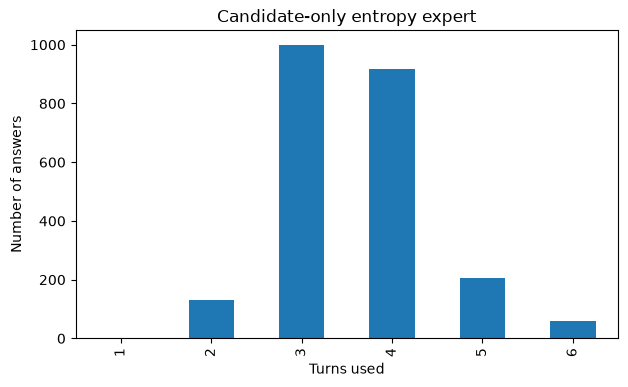

In [19]:
plt.figure(figsize=(7, 4))
turn_distribution.plot(kind="bar")
plt.xlabel("Turns used")
plt.ylabel("Number of answers")
plt.title("Candidate-only entropy expert")
plt.show()

## 5.18 Inspect failures, if any

If the expert fails any answer within six turns, print those games.

A teacher does not need to be perfect to be useful, but we should know exactly where it fails before generating millions of labels from it.

In [20]:
failed_answers = full_df.loc[
    ~full_df["solved"],
    "answer",
].tolist()

print("failed answers:", failed_answers)

for answer in failed_answers[:20]:
    print("\n", "=" * 60)
    play_expert_game(answer, verbose=True)

failed answers: ['FOYER', 'GONER', 'GRAZE', 'MATCH', 'SWORE', 'TATTY', 'WASTE', 'WATCH', 'WATER', 'WIGHT', 'WILLY']

1: RAISE -> YBBBY | candidates=2315 | H=5.878
2: DETER -> BBBGG | candidates=102 | H=4.370
3: COWER -> BGBGG | candidates=26 | H=2.747
4: HOVER -> BGBGG | candidates=9 | H=1.658
5: JOKER -> BGBGG | candidates=5 | H=1.371
6: BOXER -> BGBGG | candidates=3 | H=0.918

1: RAISE -> YBBBY | candidates=2315 | H=5.878
2: DETER -> BBBGG | candidates=102 | H=4.370
3: COWER -> BGBGG | candidates=26 | H=2.747
4: HOVER -> BGBGG | candidates=9 | H=1.658
5: JOKER -> BGBGG | candidates=5 | H=1.371
6: BOXER -> BGBGG | candidates=3 | H=0.918

1: RAISE -> YYBBG | candidates=2315 | H=5.878
2: GRACE -> GGGBG | candidates=26 | H=3.013
3: GRADE -> GGGBG | candidates=5 | H=0.722
4: GRAPE -> GGGBG | candidates=4 | H=0.811
5: GRATE -> GGGBG | candidates=3 | H=0.918
6: GRAVE -> GGGBG | candidates=2 | H=1.000

1: RAISE -> BGBBB | candidates=2315 | H=5.878
2: TANGY -> YGBBB | candidates=91 | H=4.031


## 5.19 Persist expert infrastructure

Move the stable pieces into `src/tiny_wordle/expert.py`.

The notebook remains the explanation and experiment. The package becomes reusable machinery for Lab 06.

In [21]:
expert_path = Path("../src/tiny_wordle/expert.py")
expert_path.parent.mkdir(parents=True, exist_ok=True)

expert_source = r'''from __future__ import annotations

from dataclasses import dataclass
import math

import numpy as np

from tiny_wordle.game import score_string


MARK_DIGIT = {"B": 0, "Y": 1, "G": 2}
DIGIT_MARK = {0: "B", 1: "Y", 2: "G"}


def encode_feedback(feedback: str) -> int:
    value = 0
    for mark in feedback:
        value = value * 3 + MARK_DIGIT[mark]
    return value


def decode_feedback(value: int) -> str:
    digits = [0] * 5
    for i in range(4, -1, -1):
        digits[i] = value % 3
        value //= 3
    return "".join(DIGIT_MARK[d] for d in digits)


@dataclass
class EntropyExpert:
    answers: list[str]
    patterns: np.ndarray

    def __post_init__(self):
        self.word_to_index = {
            word: i for i, word in enumerate(self.answers)
        }
        self.all_indices = np.arange(
            len(self.answers),
            dtype=np.int32,
        )

    def entropy(
        self,
        guess_index: int,
        candidate_indices: np.ndarray,
    ) -> float:
        patterns = self.patterns[
            guess_index,
            candidate_indices,
        ]
        counts = np.bincount(
            patterns,
            minlength=243,
        )
        counts = counts[counts > 0]
        probabilities = counts / counts.sum()

        return float(
            -(probabilities * np.log2(probabilities)).sum()
        )

    def choose(
        self,
        candidate_indices: np.ndarray,
    ) -> int:
        if len(candidate_indices) == 0:
            raise ValueError("candidate set is empty")

        if len(candidate_indices) == 1:
            return int(candidate_indices[0])

        best_index = None
        best_entropy = -1.0
        best_word = None

        for guess_index in candidate_indices:
            guess_index = int(guess_index)
            entropy = self.entropy(
                guess_index,
                candidate_indices,
            )
            word = self.answers[guess_index]

            if (
                entropy > best_entropy + 1e-12
                or (
                    abs(entropy - best_entropy) <= 1e-12
                    and (
                        best_word is None
                        or word < best_word
                    )
                )
            ):
                best_index = guess_index
                best_entropy = entropy
                best_word = word

        return int(best_index)

    def update(
        self,
        candidate_indices: np.ndarray,
        guess_index: int,
        feedback: str,
    ) -> np.ndarray:
        pattern_id = encode_feedback(feedback)
        matches = (
            self.patterns[
                guess_index,
                candidate_indices,
            ]
            == pattern_id
        )
        return candidate_indices[matches]
'''

expert_path.write_text(expert_source)
print("Wrote", expert_path)

Wrote ../src/tiny_wordle/expert.py


## 5.20 What exactly have we built?

The expert does not "understand" Wordle in anything like the way we discuss LLM understanding.

It has:

```text
candidate set
    ↓
enumerate possible guesses
    ↓
simulate feedback partitions
    ↓
compute entropy
    ↓
choose max-information candidate
    ↓
observe real feedback
    ↓
filter candidate set
```

Everything is explicit.

That makes it valuable as a **teacher**.

For any game state, it can produce:

- exact surviving candidates;
- candidate count;
- expert next guess;
- entropy of that guess;
- exact feedback after the action.

Those become raw ingredients for Lab 06.

## 5.21 Preview: what Lab 06 can synthesize

From one expert game:

```text
CRANE -> BBGGB
```

we can generate several kinds of supervised examples.

### State interpretation

```text
History:
C R A N E -> B B G G B

Question:
Which candidate is consistent?

Answer:
PLANT
```

### Candidate validity

```text
History:
C R A N E -> B B G G B

Candidate:
CRAKE

Answer:
INVALID
```

### Action selection

```text
History:
C R A N E -> B B G G B

Next guess:
PLANT
```

The baseline told us Qwen's dominant failure is **state use**, so Lab 06 will deliberately generate supervision that teaches state semantics instead of blindly dumping complete game transcripts into SFT.

# Lab 05 checkpoint

You should now be able to explain:

1. Why a symbolic expert is useful even though our goal is to train an LLM.
2. Why candidate filtering and guess selection are separate problems.
3. How a guess partitions the remaining answer set.
4. What Shannon entropy measures in this context.
5. Why high entropy is not the same thing as high probability of immediately solving.
6. Why we encoded feedback into `0..242`.
7. Why we cache the 2,315 × 2,315 feedback matrix.
8. Why the optimized matrix must be verified against the trusted Lab 03 scorer.
9. What "candidate-only expert" means.
10. Why this expert is a teacher rather than our final product.

## Send me these outputs

Work through the lab in order. The useful checkpoints are:

- `answers: 2315`
- the candidate count after the `PLANT / CRANE` example
- entropy results for `CRANE`, `SLATE`, `AUDIO`, `FUZZY`
- feedback-matrix build/cache result
- `100 cached patterns matched the trusted scorer`
- chosen opening guess + entropy
- the full expert trace for `PLANT`
- smoke-game results
- full 2,315-game benchmark metrics

Do not jump to Lab 06 until we know whether the teacher itself has any systematic failure modes.